In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.patches as patches
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams["font.size"] = 14
mpl.rcParams["ytick.labelsize"] = 12
mpl.rcParams["xtick.labelsize"] = 12

In [2]:
class gaussian_noiser:
    def __init__(self, timesteps:int=1000, beta_max:float=2e-2, random_seed:int=42):
        self.random_seed = random_seed
        self.beta_t = np.linspace(0.0, beta_max, timesteps+1)
        expand_points = np.linspace(-10, 10, 100)
        self.xx, self.yy = np.meshgrid(expand_points, expand_points)
        self.plot_grid = np.stack([self.xx,self.yy], axis=-1)
        self.id = np.eye(2,2)#+1e-5

    def get_alpha_t(self, timestep):
        return 1 - self.beta_t[timestep]

    def get_alpha_bar_t(self, timestep):
        timesteps = np.arange(0, timestep+1, 1, dtype=int)
        alphas = self.get_alpha_t(timestep=timesteps)
        return np.prod(alphas)
    
    def get_gauss_plot(self, xt, timestep):
        sigma = 1.0*self.beta_t[timestep]
        A = 1.0/np.sqrt(2.0*np.pi*sigma)
        centered_grid = self.plot_grid - xt
        dists = np.linalg.norm(centered_grid, axis=-1)
        exp = np.exp(-(dists)**2/(2*sigma**2))
        return A*exp

    def get_gauss_contours(self, xts, timesteps):
        gauss_contours = np.array([self.get_gauss_plot(xt=xt, timestep=timestep) for xt, timestep in zip(xts, timesteps)])
        return gauss_contours
    
    def sample_noise_transition(self, xt, timestep):
        beta_t = self.beta_t[timestep]
        sigma = self.id*beta_t
        sample = np.random.multivariate_normal(mean=np.sqrt(1.0-beta_t)*xt, cov=sigma, size=1)
        return sample

    def sample_x0_xt_transition(self, x0, timestep):
        alpha_bar = self.get_alpha_bar_t(timestep=timestep)
        sample = np.random.multivariate_normal(mean=np.sqrt(alpha_bar)*x0, cov=self.id*(1-alpha_bar))
        return sample

    def get_reverse_gauss_params(self, xt, x0, timestep):
        alpha_bar_t = self.get_alpha_bar_t(timestep=timestep)
        alpha_bar_t_m1 = self.get_alpha_bar_t(timestep=timestep-1)
        alpha_t = self.get_alpha_t(timestep=timestep)
        mean = (np.sqrt(alpha_t)*(1.0-alpha_bar_t_m1)*xt + np.sqrt(alpha_bar_t_m1)*(1-alpha_t)*x0)/(1.0-alpha_bar_t)
        variance = (1.0-alpha_t)*(1-alpha_bar_t_m1)*self.id/(1.0-alpha_bar_t)
        return mean, variance

    def sample_reverse_x0_trans(self, xt, x0, timestep):
        mean, variance = self.get_reverse_gauss_params(xt=xt, x0=x0, timestep=timestep)
        sample = np.random.multivariate_normal(mean=mean, cov=variance)
        return sample
    
    def get_single_transition_probs(self, xt, timestep):
       centered_grid_d1 = xt[0] - self.expand_d1
       centered_grid_d2 = xt[1] - self.expand_d2
       dist_d1, dist_d2 = self.gauss_func(
           timestep=timestep, 
           centered_grid1=centered_grid_d1,
           centered_grid2=centered_grid_d2
           )
       return dist_d1, dist_d2
        

In [3]:
def mvn_pdf(grid, mean, cov):
    """
    Multivariate normal PDF evaluated on a grid.
    grid: (..., 2) array of points
    mean: (2,)
    cov : (2,2)
    returns: (...) array
    """
    mean = np.asarray(mean, dtype=float)
    cov = np.asarray(cov, dtype=float)
    inv = np.linalg.inv(cov)
    det = np.linalg.det(cov)

    diff = grid - mean
    expo = -0.5 * np.einsum("...i,ij,...j->...", diff, inv, diff)
    norm = 1.0 / np.sqrt((2.0 * np.pi) ** 2 * det)
    return norm * np.exp(expo)

def mixture_pdf(grid, means, covs, weights=None):
    means = np.asarray(means, dtype=float)
    k = means.shape[0]

    if weights is None:
        weights = np.ones(k, dtype=float) / k
    else:
        weights = np.asarray(weights, dtype=float)
        weights = weights / weights.sum()

    out = np.zeros(grid.shape[:-1], dtype=float)
    for w, m, c in zip(weights, means, covs):
        out += w * mvn_pdf(grid, m, c)
    return out

def quantile_levels(Z, qs=(0.80, 0.88, 0.93, 0.96, 0.985, 0.995, 1.0), eps=1e-15):
    """
    Choose contour levels from quantiles of the positive values of Z
    for nicely spaced lines.
    """
    Zpos = Z[Z > eps]
    if Zpos.size == 0:
        raise ValueError("Z has no positive values above eps; check your PDF/grid.")
    return np.quantile(Zpos, qs)

def transparent_cmap(color, name):
    """
    Create a colormap that fades from transparent to the given color.
    """
    return LinearSegmentedColormap.from_list(
        name,
        [(0, (*color, 0.0)), (1, (*color, 1.0))]
    )

def alpha_fade_cmap(rgb, name, n=256, alpha_max=0.55, gamma=2.2):
    """
    rgb: tuple in [0,1]
    alpha_max: cap peak opacity (smaller = less strong at max)
    gamma > 1: slower fade near low values (less "too fast" fade)
    """
    t = np.linspace(0, 1, n)
    a = alpha_max * (t ** gamma)  # slow ramp
    colors = np.column_stack([
        np.full(n, rgb[0]),
        np.full(n, rgb[1]),
        np.full(n, rgb[2]),
        a
    ])
    return ListedColormap(colors, name=name)

def log_levels(Z, n_levels=120, floor_frac=1e-4):
    """
    Log-spaced levels from (max * floor_frac) .. max.
    Gives nicer tail structure and avoids over-saturating peaks.
    """
    zmax = float(np.max(Z))
    zmin = zmax * floor_frac
    return np.geomspace(zmin, zmax, n_levels)

[['grey'], ['grey'], ['grey'], ['grey']]


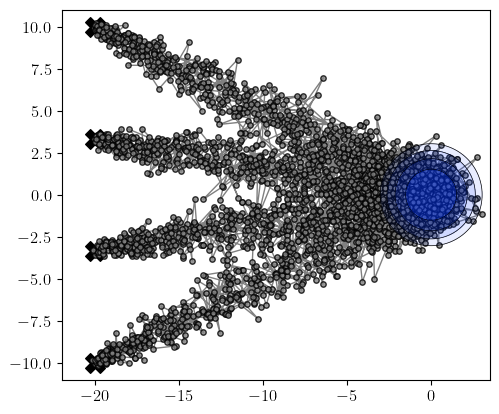

In [4]:
np.random.seed(42)
fig, ax = plt.subplots()
num_timesteps = 1000
noiser = gaussian_noiser(timesteps=num_timesteps)
x_place = -20
y_scale = 0.5
y_places = np.linspace(x_place*y_scale, -x_place*y_scale, 4)
x0s = np.vstack([np.array([x_place, y_place]) for y_place in y_places])
ax.scatter(x0s[:,0], x0s[:,1], c="k", marker="X", s=200.0)

prior_mean = np.array([0.0, 0.0])
prior_cov  = np.eye(2)*1.0  # unit Gaussian
lim = 5.0
n = 500
x = np.linspace(-lim, lim, n)
y = np.linspace(-lim, lim, n)
xx, yy = np.meshgrid(x, y)
grid = np.stack([xx, yy], axis=-1)
prior = mvn_pdf(grid, prior_mean, prior_cov)

prior_levels = log_levels(prior, n_levels=5, floor_frac=1e-2)
red_cmap  = alpha_fade_cmap((1.0, 0.0, 0.0), "red_alpha",  alpha_max=0.6, gamma=0.4)
blue_cmap = alpha_fade_cmap((0.0, 0.2, 1.0), "blue_alpha", alpha_max=0.6, gamma=0.4)
#ax.contour(xx, yy, prior, levels=prior_levels, colors="k", linewidths=0.5)


timesteps = np.arange(1, num_timesteps+1, 1)
n_samples_per_x0 = 1
colors = [[f"grey" for _ in range(n_samples_per_x0)] for i in range(len(y_places))]
print(colors)
tot_traj_list = []
for x0 in x0s:
    traj_per_x0 = []
    for _ in range(n_samples_per_x0):
        sample_traj = []
        for timestep in timesteps:
            xt = noiser.sample_x0_xt_transition(x0=x0, timestep=timestep)
            sample_traj.append(xt)
        samples = np.vstack(sample_traj)
        traj_per_x0.append(samples)
    tot_traj_list.append(traj_per_x0)

xs = np.linspace(x_place, 0.0, 5)
labels = ["$t=0$", r"$t=\frac{T}{4}$", r"$t=\frac{T}{2}$", r"$t=\frac{3T}{4}$", "$t=T$"]
#ax.set_xticks(ticks=xs, labels=labels)
ax.set_xlim([x_place-2, 3.5])
ax.set_ylim([np.min(y_places)-1.0, np.max(y_places)+1.0])
#ax.set_yticks([])
plot_interval = 1
indices = np.arange(0, 1000, plot_interval)
for traj_per_x0, color_per_x0 in zip(tot_traj_list, colors):
    for traj, color in zip(traj_per_x0, color_per_x0):
        plot_points = np.vstack([traj[index] for index in indices])
        ax.scatter(plot_points[:,0], plot_points[:,1], c=color, alpha=0.8, edgecolors="k", s=15.0)
        ax.plot(plot_points[:,0], plot_points[:,1], c=color, lw=1, zorder=-1)
ax.set_aspect("equal")
#ax.set_frame_on(False)
ax.contourf(xx, yy, prior, levels=prior_levels, cmap=blue_cmap)
ax.contour(xx, yy, prior, levels=prior_levels, colors="k", linewidths=0.5)

[ 6.  0. -6.]


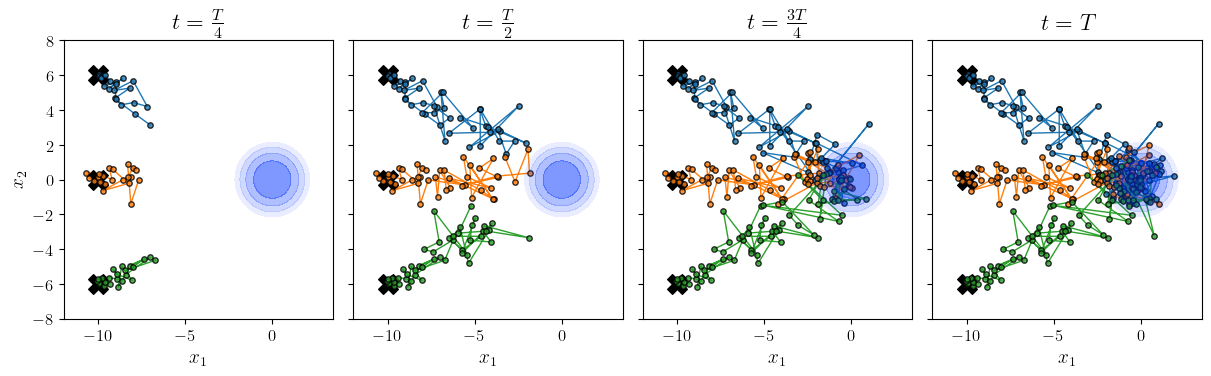

In [74]:
fig, axs = plt.subplots(1,4, figsize=(12,8), sharey=True, layout="constrained", gridspec_kw={"wspace":0.05})
num_timesteps = 1000
noiser = gaussian_noiser(timesteps=num_timesteps)
x_place = -10
y_scale = 0.6
y_places = np.linspace((x_place+20)*y_scale, -(x_place+20)*y_scale, 3)
print(y_places)
x0s = np.vstack([np.array([x_place, y_place]) for y_place in y_places])

prior_mean = np.array([0.0, 0.0])
prior_cov  = np.eye(2)*0.5  # unit Gaussian
lim = 5.0
n = 500
x = np.linspace(-lim, lim, n)
y = np.linspace(-lim, lim, n)
xx, yy = np.meshgrid(x, y)
grid = np.stack([xx, yy], axis=-1)
prior = mvn_pdf(grid, prior_mean, prior_cov)

prior_levels = log_levels(prior, n_levels=5, floor_frac=1e-2)
red_cmap  = alpha_fade_cmap((1.0, 0.0, 0.0), "red_alpha",  alpha_max=0.6, gamma=0.4)
blue_cmap = alpha_fade_cmap((0.0, 0.2, 1.0), "blue_alpha", alpha_max=0.6, gamma=0.4)

n_samples_per_x0 = 1
colors = [[f"C{i}" for _ in range(n_samples_per_x0)] for i in range(len(y_places))]
tot_traj_list = []
timesteps = np.arange(1, num_timesteps+1, 1)
for x0 in x0s:
    traj_per_x0 = []
    for _ in range(n_samples_per_x0):
        sample_traj = []
        for timestep in timesteps:
            xt = noiser.sample_x0_xt_transition(x0=x0, timestep=timestep)
            sample_traj.append(xt)
        samples = np.vstack(sample_traj)
        traj_per_x0.append(samples)
    tot_traj_list.append(traj_per_x0)

timestep_divisions = [250, 500, 750, 1000]
plot_interval = 10

axis_labels = [
    #r"$t=\frac{T}{10}$",
    r"$t=\frac{T}{4}$",
    r"$t=\frac{T}{2}$",
    r"$t=\frac{3T}{4}$",
    r"$t=T$"
]

for i, ax, timestep_div, label in zip(range(len(axs)), axs, timestep_divisions, axis_labels):
    ax.scatter(x0s[:,0], x0s[:,1], c="k", marker="X", s=200.0)
    ax.set_xlim([x_place-2, 3.5])
    ax.set_ylim([np.min(y_places)-2.0, np.max(y_places)+2.0])
    ax.set_xlabel(r"$x_1$")
    if i == 0:
        ax.set_ylabel(r"$x_2$")
    for traj_per_x0, color_per_x0 in zip(tot_traj_list, colors):
        for traj, color in zip(traj_per_x0, color_per_x0):
            indices = np.arange(0, timestep_div, plot_interval)
            plot_points = np.vstack([traj[index] for index in indices])
            ax.scatter(plot_points[:,0], plot_points[:,1], c=color, alpha=0.8, edgecolors="k", s=15.0)
            ax.plot(plot_points[:,0], plot_points[:,1], c=color, lw=1, zorder=-1)
    ax.set_title(label, y=1.0, pad=8.0)
    ax.contourf(xx, yy, prior, levels=prior_levels, cmap=blue_cmap)
    #ax.contour(xx, yy, prior, levels=prior_levels, colors="k", linewidths=0.5)
    ax.set_aspect("equal")
plt.savefig("gauss_noise.pdf", bbox_inches='tight')

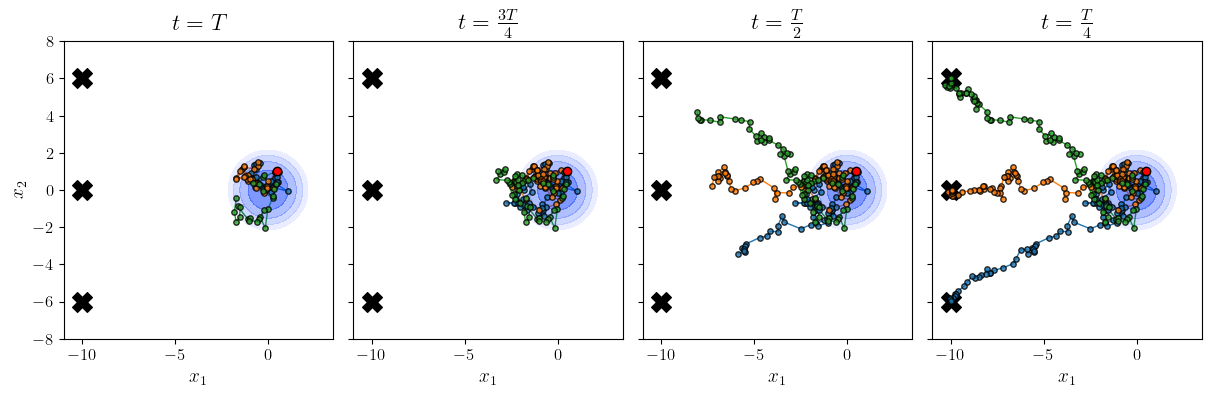

In [73]:
np.random.seed(42)
fig, axs = plt.subplots(1,4, figsize=(12,8), sharey=True, layout="constrained", gridspec_kw={"wspace":0.05})
num_timesteps = 1000
noiser = gaussian_noiser(timesteps=num_timesteps)
x_place = -10.0
y_scale = 0.6
y_places = np.linspace((x_place)*y_scale, -(x_place)*y_scale, 3)
x0s = np.vstack([np.array([x_place, y_place]) for y_place in y_places])


prior_mean = np.array([0.0, 0.0])
prior_cov  = np.eye(2)*0.5  # unit Gaussian
lim = 5.0
n = 500
x = np.linspace(-lim, lim, n)
y = np.linspace(-lim, lim, n)
xx, yy = np.meshgrid(x, y)
grid = np.stack([xx, yy], axis=-1)
prior = mvn_pdf(grid, prior_mean, prior_cov)
prior_levels = log_levels(prior, n_levels=5, floor_frac=1e-2)
red_cmap  = alpha_fade_cmap((1.0, 0.0, 0.0), "red_alpha",  alpha_max=0.6, gamma=0.4)
blue_cmap = alpha_fade_cmap((0.0, 0.2, 1.0), "blue_alpha", alpha_max=0.6, gamma=0.4)


xT = np.array([0.5, 1.0])


n_samples_per_x0 = 1
colors = [[f"C{i}" for _ in range(n_samples_per_x0)] for i in range(len(y_places))]
tot_traj_list = []
timesteps = np.arange(1, num_timesteps+1, 1)
for x0 in x0s:
    traj_per_x0 = []
    for _ in range(n_samples_per_x0):
        sample_traj = []
        for timestep in timesteps:
            if timestep == 1:
                xt = xT
            else:
                xt = sample_traj[-1]
            t = num_timesteps - timestep + 1
            xt = noiser.sample_reverse_x0_trans(xt=xt, timestep=t, x0=x0)
            sample_traj.append(xt)
        samples = np.vstack(sample_traj)
        traj_per_x0.append(samples)
    tot_traj_list.append(traj_per_x0)

axis_labels = [
    #r"$t=\frac{T}{10}$",
    r"$t=\frac{T}{4}$",
    r"$t=\frac{T}{2}$",
    r"$t=\frac{3T}{4}$",
    r"$t=T$"
]
axis_labels.reverse()

timestep_divisions = [250, 500, 750, 1000]
plot_interval = 10
for i, ax, timestep_div, label in zip(range(len(axs)), axs, timestep_divisions, axis_labels):
    ax.scatter(x0s[:,0], x0s[:,1], c="k", marker="X", s=200.0)
    ax.set_xlim([-11., 3.5])
    ax.set_ylim([np.min(y_places)-2.0, np.max(y_places)+2.0])
    ax.set_xlabel(r"$x_1$")
    if i == 0:
        ax.set_ylabel(r"$x_2$")
    
    ax.contourf(xx, yy, prior, levels=prior_levels, cmap=blue_cmap)
    #ax.contour(xx, yy, prior, levels=prior_levels, colors="k", linewidths=0.5)

    for traj_per_x0, color_per_x0 in zip(tot_traj_list, colors):
        for traj, color in zip(traj_per_x0, color_per_x0):
            indices = np.arange(0, timestep_div, plot_interval)
            plot_points = np.vstack([traj[index] for index in indices])
            ax.scatter(plot_points[:,0], plot_points[:,1], c=color, alpha=0.8, edgecolors="k", s=15.0)
            ax.plot(plot_points[:,0], plot_points[:,1], c=color, lw=1, zorder=-1)
    ax.set_title(label, y=1.0, pad=8.0)
    ax.scatter(xT[0], xT[1], c="red", edgecolors="k")
    ax.set_aspect("equal")
plt.savefig("gauss_denoise.pdf", bbox_inches='tight')
